# Feature Selection Techniques in Heart Disease Prediction

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [36]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head(10)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [37]:
df.shape



(270, 14)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [39]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [40]:
df.isnull().sum()



Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [41]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

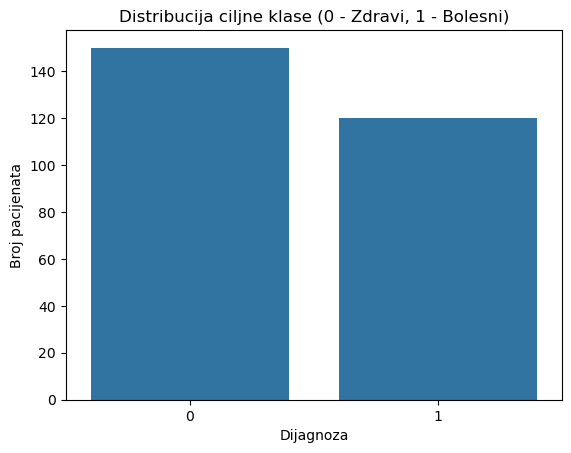

In [42]:
sns.countplot(x='Heart Disease', data=df)
plt.title('Distribucija ciljne klase (0 - Zdravi, 1 - Bolesni)')
plt.xlabel('Dijagnoza')
plt.ylabel('Broj pacijenata')
plt.show()

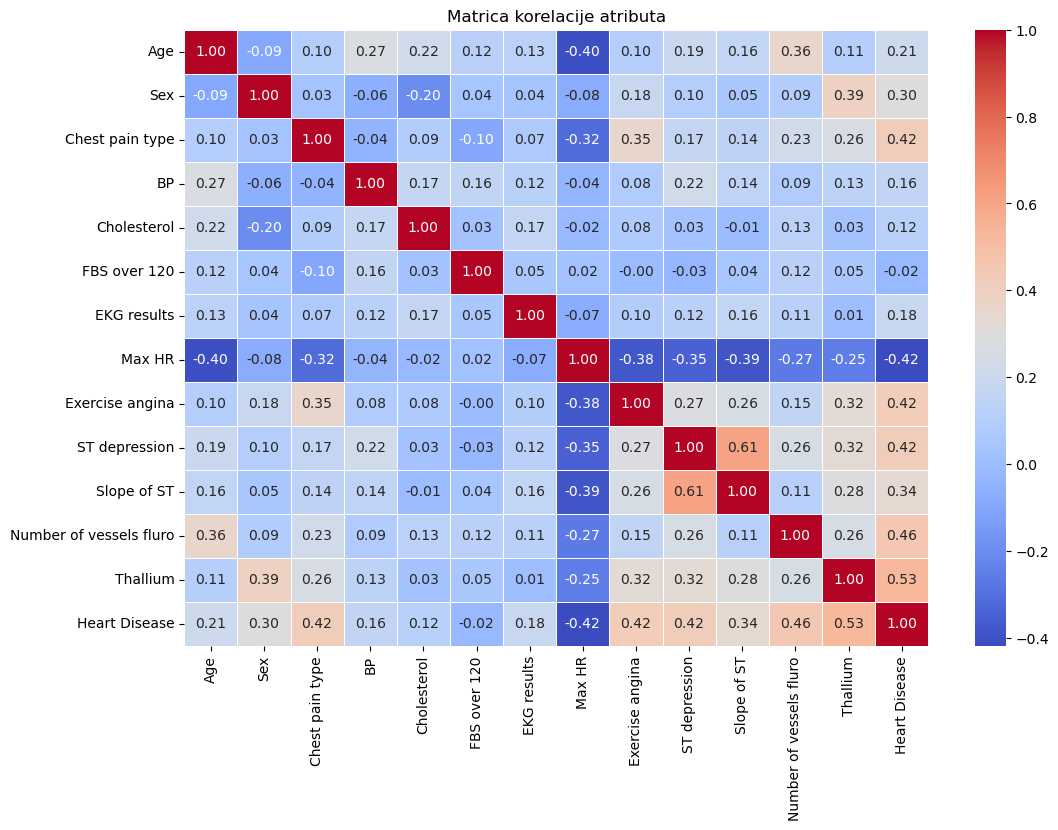

In [43]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrica korelacije atributa')
plt.show()

## Podela za trening

In [44]:

X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Helper

In [58]:
def evaluate_model(model, X_test_data, y_test_true, name):
    y_pred = model.predict(X_test_data)
    
    metrics = {
        "Accuracy": accuracy_score(y_test_true, y_pred),
        "Precision": precision_score(y_test_true, y_pred),
        "Recall": recall_score(y_test_true, y_pred),
        "F1": f1_score(y_test_true, y_pred)
    }
    
    
    print(f"{name} Results")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")
        
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return metrics

### Baseline model

Baseline Results
Accuracy: 0.8889
Precision: 0.8571
Recall: 0.8571
F1: 0.8571


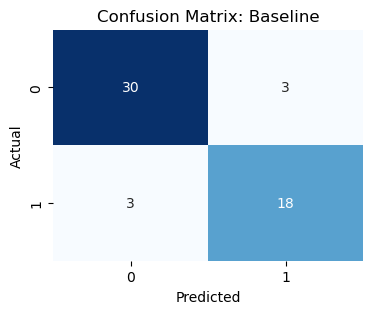

In [59]:
model = LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

baseline_results = evaluate_model(model, X_test_scaled, y_test, "Baseline")

## Filter metode

### Chi-square selekcija 

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)


In [61]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=5)
X_train_filter = selector.fit_transform(X_train_mm, y_train)
X_test_filter = selector.transform(X_test_mm)

selected_features_filter = X.columns[selector.get_support()]
print("Chi-square atributi:", selected_features_filter)

Chi-square atributi: Index(['Exercise angina', 'ST depression', 'Slope of ST',
       'Number of vessels fluro', 'Thallium'],
      dtype='object')


Chi-square Results
Accuracy: 0.8333
Precision: 0.8333
Recall: 0.7143
F1: 0.7692


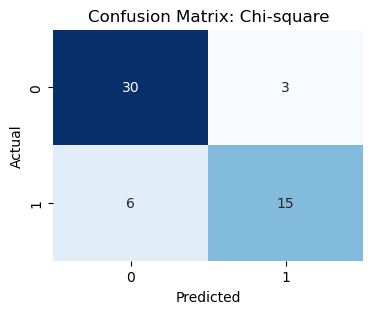

In [62]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_filter, y_train)

y_pred = model.predict(X_test_filter)

filter_results = evaluate_model(model, X_test_filter, y_test, "Chi-square")

### Mutal Information

In [65]:
from sklearn.feature_selection import mutual_info_classif

selector_mi = SelectKBest(score_func=mutual_info_classif, k=5)
X_train_mi = selector_mi.fit_transform(X_train_scaled, y_train)
X_test_mi = selector_mi.transform(X_test_scaled)

selected_features_mi = X.columns[selector_mi.get_support()]
print(f"Mutual Information odabrani atributi: {list(selected_features_mi)}")

Mutual Information odabrani atributi: ['Chest pain type', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


Mutual Info Results
Accuracy: 0.8519
Precision: 0.8421
Recall: 0.7619
F1: 0.8000


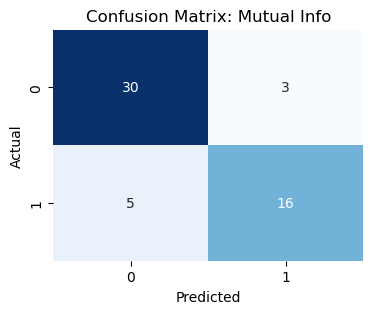

In [66]:
model_mi = LogisticRegression(max_iter=1000)
model_mi.fit(X_train_mi, y_train)

mi_results = evaluate_model(model_mi, X_test_mi, y_test, "Mutual Info")

## Wrapper metode

### RFE

In [68]:
from sklearn.feature_selection import RFE

rfe = RFE(model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

selected_indices = rfe.get_support(indices=True)


selected_features = X.columns[selected_indices]
print(f"RFE odabrani atributi: {list(selected_features)}")

RFE odabrani atributi: ['Chest pain type', 'Exercise angina', 'ST depression', 'Number of vessels fluro', 'Thallium']


RFE Results
Accuracy: 0.9074
Precision: 1.0000
Recall: 0.7619
F1: 0.8649


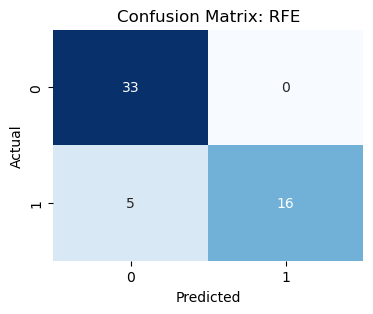

In [69]:
model.fit(X_train_rfe, y_train)
y_pred = model.predict(X_test_rfe)

rfe_metrics = evaluate_model(model, X_test_rfe, y_test, "RFE")

### SFS

SFS odabrani atributi: ['Chest pain type', 'BP', 'ST depression', 'Number of vessels fluro', 'Thallium']
Forward Selection Results
Accuracy: 0.8519
Precision: 0.8421
Recall: 0.7619
F1: 0.8000


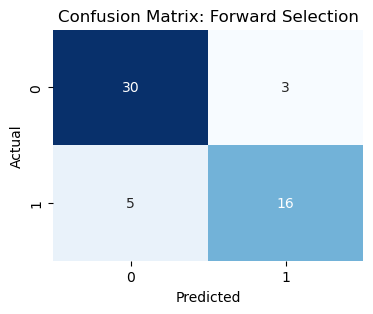

In [71]:
from sklearn.feature_selection import SequentialFeatureSelector

lr_wrapper = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(lr_wrapper, n_features_to_select=5, direction='forward')
X_train_sfs = sfs.fit_transform(X_train_scaled, y_train)
X_test_sfs = sfs.transform(X_test_scaled)

selected_features_sfs = X.columns[sfs.get_support()]
print("SFS odabrani atributi:", list(selected_features_sfs))

lr_wrapper.fit(X_train_sfs, y_train)
sfs_results = evaluate_model(lr_wrapper, X_test_sfs, y_test, "Forward Selection")

## EMBEDDED

### Lasso

In [72]:
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

lasso_model.fit(X_train_scaled, y_train)

selected_features_lasso = X.columns[lasso_model.coef_[0] != 0]
print("LASSO atributi:", selected_features_lasso)


LASSO atributi: Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')


Lasso Results
Accuracy: 0.9074
Precision: 0.9000
Recall: 0.8571
F1: 0.8780


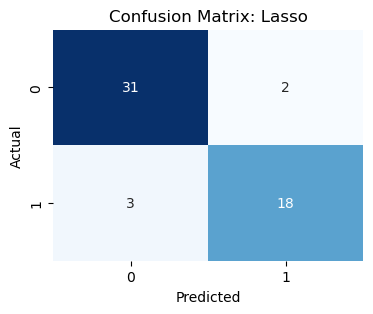

In [73]:
X_train_lasso = X_train_scaled[:, lasso_model.coef_[0] != 0]
X_test_lasso = X_test_scaled[:, lasso_model.coef_[0] != 0]

model.fit(X_train_lasso, y_train)
y_pred = model.predict(X_test_lasso)

lasso_metrics = evaluate_model(model, X_test_lasso, y_test, "Lasso")

### Random forest

Random Forest Embedded atributi: ['Age', 'Chest pain type', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Number of vessels fluro', 'Thallium']
RF Importance Results
Accuracy: 0.8333
Precision: 0.8750
Recall: 0.6667
F1: 0.7568


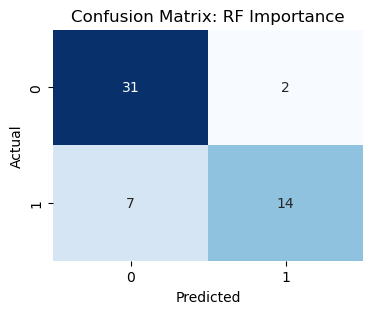

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

embed_rf_selector = SelectFromModel(rf_selector, prefit=True)
X_train_rf = embed_rf_selector.transform(X_train_scaled)
X_test_rf = embed_rf_selector.transform(X_test_scaled)

selected_features_rf = X.columns[embed_rf_selector.get_support()]
print("Random Forest Embedded atributi:", list(selected_features_rf))

lr_rf = LogisticRegression(max_iter=1000)
lr_rf.fit(X_train_rf, y_train)
rf_embed_results = evaluate_model(lr_rf, X_test_rf, y_test, "RF Importance")

In [77]:

results = pd.DataFrame([
    baseline_results,
    filter_results,
    mi_results,
    rfe_metrics,
    sfs_results,
    lasso_metrics,
    rf_embed_results 
], index=["Baseline (Svi)", 
    "Filter (Chi2)", 
     "Filter (Mutual Info)",
    "Wrapper (RFE)", 
    "Wrapper (Forward)", 
    "Embedded (LASSO)", 
    "Embedded (RF)"])
results



,Accuracy,Precision,Recall,F1
Baseline (Svi),0.888889,0.857143,0.857143,0.857143
Filter (Chi2),0.833333,0.833333,0.714286,0.769231
Filter (Mutual Info),0.851852,0.842105,0.761905,0.800000
Wrapper (RFE),0.907407,1.000000,0.761905,0.864865
Wrapper (Forward),0.851852,0.842105,0.761905,0.800000
Embedded (LASSO),0.907407,0.900000,0.857143,0.878049
Embedded (RF),0.833333,0.875000,0.666667,0.756757


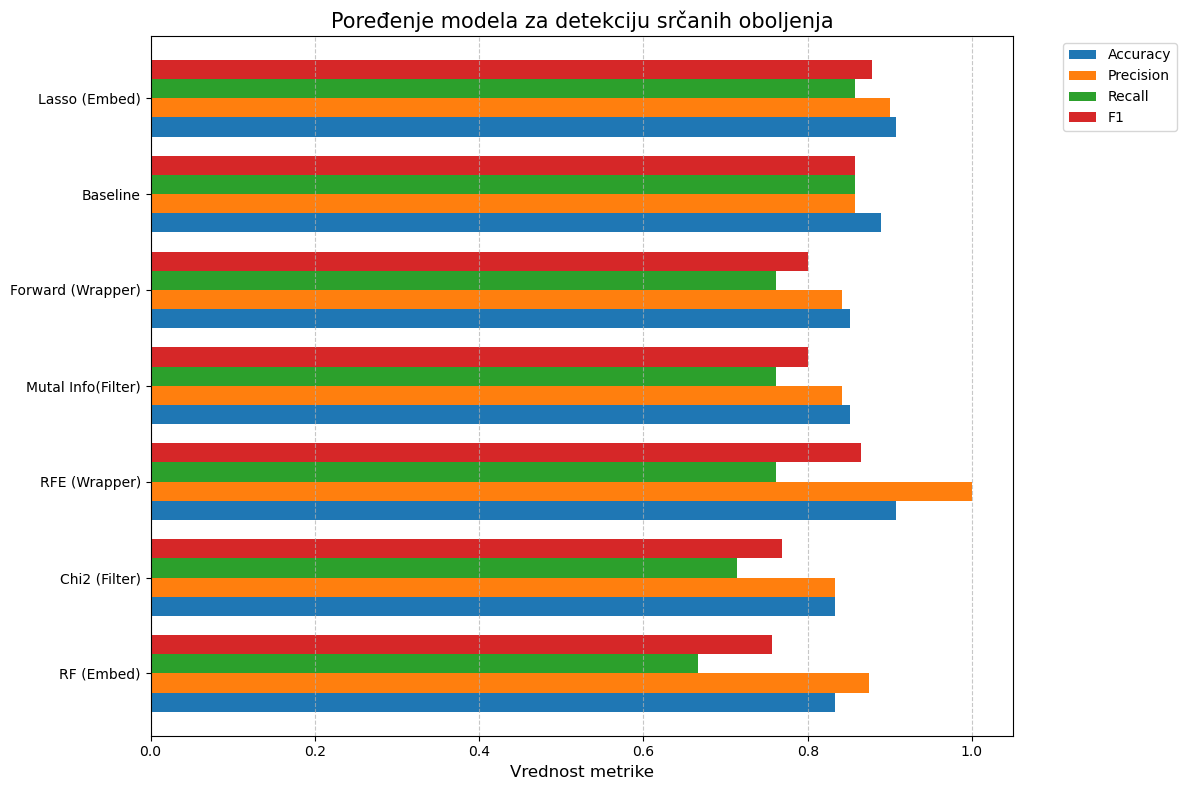

In [78]:
import matplotlib.pyplot as plt

final_comparison = pd.DataFrame([
    baseline_results,
    filter_results,
    mi_results,
    rfe_metrics,
    sfs_results,
    lasso_metrics,
    rf_embed_results
], index=[
    "Baseline", "Chi2 (Filter)","Mutal Info(Filter)", "RFE (Wrapper)", 
    "Forward (Wrapper)", "Lasso (Embed)", "RF (Embed)"
])

final_comparison = final_comparison.sort_values(by="Recall", ascending=True)

ax = final_comparison.plot(kind='barh', figsize=(12, 8), width=0.8)
plt.title('Poređenje modela za detekciju srčanih oboljenja', fontsize=15)
plt.xlabel('Vrednost metrike', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()